Sample loaded: 12,650,009 raw trips → 1,130,635 aggregated rows


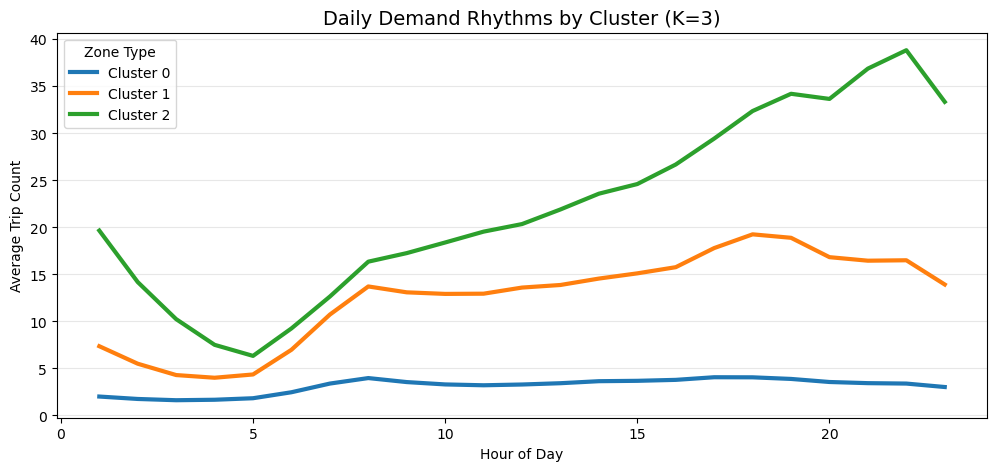

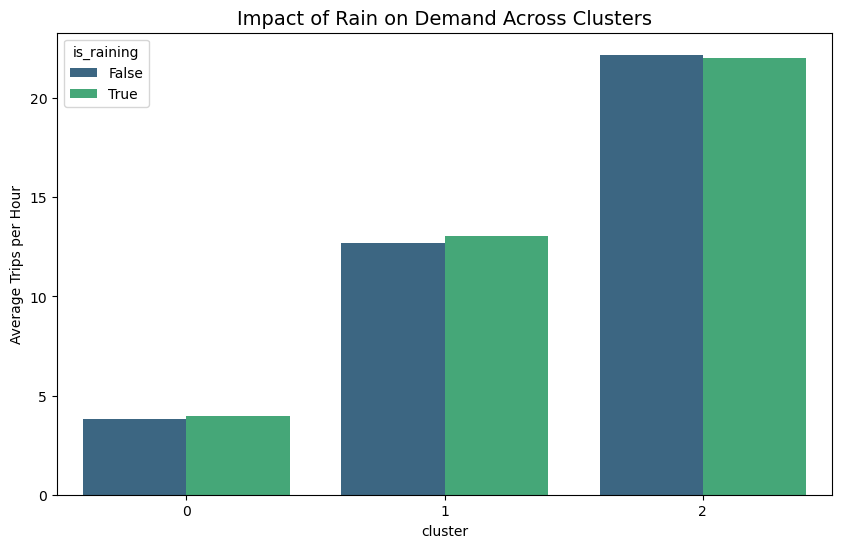

Final cluster summary
is_raining      False       True  % Increase
cluster                                     
0            3.830165   3.984557    4.030950
1           12.716287  13.024712    2.425438
2           22.191259  22.045419   -0.657194


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler

path = 'combined_2024_with_features_with_weather.parquet'

NEEDED_COLS = [
    'pu_zone_id', 'pickup_hour', 'day_of_week',
    'HourlyPrecipitation', 'DailySnowfall', 'HourlyWindSpeed',
    'HourlyDryBulbTemperature', 'is_weekend', 'is_rush_hour'
]

df_raw = pd.read_parquet(path, columns=NEEDED_COLS).sample(frac=0.05, random_state=42)

# coerce string weather columns to numeric
df_raw['HourlyPrecipitation'] = pd.to_numeric(df_raw['HourlyPrecipitation'], errors='coerce').fillna(0)
df_raw['DailySnowfall'] = pd.to_numeric(df_raw['DailySnowfall'], errors='coerce').fillna(0)
df_raw['HourlyWindSpeed'] = pd.to_numeric(df_raw['HourlyWindSpeed'], errors='coerce').fillna(0)

# aggregate to trip counts per zone/hour/conditions (each raw row = 1 trip)
df = (
    df_raw
    .groupby(['pu_zone_id', 'pickup_hour', 'day_of_week', 'is_weekend', 'is_rush_hour',
              'HourlyPrecipitation', 'DailySnowfall', 'HourlyWindSpeed', 'HourlyDryBulbTemperature'])
    .size()
    .reset_index(name='total_trips')
    .rename(columns={
        'pu_zone_id': 'zone_id',
        'pickup_hour': 'hour',
        'HourlyPrecipitation': 'precipitation',
        'DailySnowfall': 'snowfall',
        'HourlyWindSpeed': 'windspeed_10m',
        'HourlyDryBulbTemperature': 'temperature_2m',
    })
)

print(f'Sample loaded: {len(df_raw):,} raw trips → {len(df):,} aggregated rows')

# make the behaviour profiles
zone_profiles = df.groupby(['zone_id', 'hour'])['total_trips'].mean().unstack().fillna(0)

scaler = StandardScaler()
zone_profiles_scaled = scaler.fit_transform(zone_profiles)

# mini batch k means
mbk = MiniBatchKMeans(n_clusters=3, batch_size=100, random_state=42, n_init='auto')
zone_profiles['cluster'] = mbk.fit_predict(zone_profiles_scaled)

df = df.merge(zone_profiles[['cluster']], left_on='zone_id', right_index=True, how='left')

# plot these daily rythms
plt.figure(figsize=(12, 5))
cluster_means = zone_profiles.groupby('cluster').mean()

for i in range(len(cluster_means)):
    plt.plot(cluster_means.columns, cluster_means.iloc[i], label=f'Cluster {i}', lw=3)

plt.title('Daily Demand Rhythms by Cluster (K=3)', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Average Trip Count')
plt.legend(title='Zone Type')
plt.grid(axis='y', alpha=0.3)
plt.show()

# daily rhthms cluster graph
df['is_raining'] = df['precipitation'] > 0
rain_analysis = df.groupby(['cluster', 'is_raining'])['total_trips'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=rain_analysis, x='cluster', y='total_trips', hue='is_raining', palette='viridis')
plt.title('Impact of Rain on Demand Across Clusters', fontsize=14)
plt.ylabel('Average Trips per Hour')
plt.show()

# summary numbers
print("Final cluster summary")
rain_pivot = rain_analysis.pivot(index='cluster', columns='is_raining', values='total_trips')
rain_pivot['% Increase'] = ((rain_pivot[True] - rain_pivot[False]) / rain_pivot[False]) * 100

print(rain_pivot)

finding the percentiles and which zones shouldnt be used in zone clustering

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# find total trips per zone
zone_activity = df.groupby('zone_id')['total_trips'].sum().sort_values()

# find percentiles
p05 = zone_activity.quantile(0.05)
p10 = zone_activity.quantile(0.10)
p25 = zone_activity.quantile(0.25)


print(f"Statistics ")
print(f"5th Percentile: {p05:.2f} trips (Removes 5% of zones)")
print(f"10th Percentile: {p10:.2f} trips (Removes 10% of zones)")
print(f"25th Percentile (Q1): {p25:.2f} trips (Removes 25% of zones)")

1. Handling Sparsity (The "Must-Do")

Recommendation: Do this immediately. NYC has some taxi zones (like the ones in the middle of parks or industrial cemeteries) that have almost zero data. If you include them, your K=3 clusters might end up being:

High Activity

Low Activity

The 3 "Empty" zones that have 1 trip a month.
Action: Filter out any zone_id that doesn't have at least a minimum threshold of activity (e.g., at least 1 trip per day on average). This ensures your clusters are based on reliable patterns.

Step 1: Handling Sparsity (Data Cleaning)

What it does: Filters out zones with extremely low total trip counts.

Why it does it: "Quiet" zones (like parks or industrial docks) don't have enough data to form a reliable "rhythm." Including them creates "outlier clusters" that don't represent real urban behavior.

How it helps: It ensures your clusters are based on statistically significant patterns, making your final weather analysis much more reliable.

In [ ]:
# total trips per zone
zone_activity = df.groupby('zone_id')['total_trips'].sum()

# find cut off point
lower_cutoff = zone_activity.quantile(0.05)
upper_cutoff = zone_activity.quantile(0.95)

# filter zones
active_zones = zone_activity[
    (zone_activity >= lower_cutoff) & 
    (zone_activity <= upper_cutoff)
].index

df_filtered = df[df['zone_id'].isin(active_zones)].copy()

print(f"Range Filtering")
print(f"Lower Threshold (5%): {lower_cutoff:.2f} trips")
print(f"Upper Threshold (95%): {upper_cutoff:.2f} trips")
print(f"Zones remaining: {len(active_zones)} (Removed {len(zone_activity) - len(active_zones)} outliers)")

3. Weekend vs. Weekday (The "Domain Insight")

Recommendation: Do this if you want to impress.
NYC is a "Tale of Two Cities." A business district in Lower Manhattan is a ghost town on Sunday, while Williamsburg is booming.

The Logic: Currently, your profile averages all days together. This "blurs" the data.

The Action: Change your groupby to ['zone_id', 'day_type', 'hour'].

Day Type 0: Monday–Friday

Day Type 1: Saturday–Sunday
Your matrix will now have 48 columns instead of 24. This will much more accurately separate "Work" zones from "Play" zones.

Step 2: Temporal Engineering (48-Hour Profile)

What it does: Splits the data into two profiles per zone: one for Weekdays (Mon-Fri) and one for Weekends (Sat-Sun).

Why it does it: A "Commuter" zone and a "Nightlife" zone might look similar if you average them together, but they are opposites on a Saturday morning.

How it helps: It adds a second dimension of "identity" to each zone, allowing the model to distinguish between "Work" and "Play" areas.

In [ ]:
# Categorise days
df_filtered['day_type'] = df_filtered['day_of_week'].apply(lambda x: 'weekday' if x < 5 else 'weekend')

# create matrix
profiles_48h = df_filtered.groupby(['zone_id', 'day_type', 'hour'])['total_trips'].mean().unstack(level=[1, 2]).fillna(0)
print(f" {profiles_48h.shape}")

4. Min-Max Scaling vs. Standard Scaling

Recommendation: Switch to Min-Max.

Why: StandardScaler looks at how "extreme" a value is compared to the average. MinMaxScaler looks at the shape.

Example: If you want a "Morning Peak" zone to be grouped with another "Morning Peak" zone—regardless of whether one is 10x busier than the other—Min-Max is technically superior for "profile" clustering.

Step 3: Min-Max Scaling (Normalization)

What it does: Rescales each zone's demand to a range between 0 and 1.

Why it does it: K-Means uses "Euclidean distance." Without scaling, a busy zone with 1,000 trips would be "far" from a small zone with 10 trips, even if they have the exact same schedule.

How it helps: It forces the algorithm to focus on the shape of the day (the rhythm) rather than the raw volume of passengers.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
profiles_scaled = scaler.fit_transform(profiles_48h.T).T

4. PCA (The "Academic Gold Standard")

Recommendation: Highly Recommended.
Using Principal Component Analysis (PCA) before K-Means is a classic "advanced" data science move.

The Logic: Instead of 24 separate hourly features, PCA might find that 90% of the difference between neighborhoods can be explained by just 3 "Components" (e.g., Morning-ness, Evening-ness, and Weekend-ness).

The Benefit: It cleans up the "noise" and usually results in much tighter, more logical clusters.

Step 4: PCA (Dimensionality Reduction)

What it does: Compresses 48 features down into a few "Principal Components."

Why it does it: Many hours are redundant (e.g., 3 AM and 4 AM are usually both zero). PCA finds the core "trends" (e.g., "The Morning Spike" or "The Weekend Surge").

How it helps: It removes noise and prevents the "curse of dimensionality," usually resulting in much tighter and more distinct clusters.

In [ ]:
from sklearn.decomposition import PCA

# Keep enough components to explain 95% of the behavioral variance
pca = PCA(n_components=0.95)
profiles_pca = pca.fit_transform(profiles_scaled)

print(f"PCA reduced 48 hours to {profiles_pca.shape[1]} behavioral components.")

In [ ]:
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

# range of clusters to test
K_range = range(2, 13)
inertias = []
silhouette_avg = []

for k in K_range:
    mbk = MiniBatchKMeans(n_clusters=k, batch_size=100, random_state=42, n_init='auto')
    mbk.fit(profiles_pca)
    inertias.append(mbk.inertia_)
    score = silhouette_score(profiles_pca, mbk.labels_)
    silhouette_avg.append(score)

# plot results
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Sum of Squares)', color='tab:blue')
ax1.plot(K_range, inertias, 'bx-', label='Inertia')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(K_range, silhouette_avg, 'ro-', label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Tuning K: Elbow Method & Silhouette Score')
plt.show()


Step 5: Mini-Batch K-Means (Clustering)

What it does: Groups the PCA-compressed zones into 3 distinct clusters.

Why it does it: To simplify the city into three manageable "types" of neighborhoods.

How it helps: It provides the final labels you need to prove that "Rain affects the Hub Cluster differently than the Residential Cluster."

In [ ]:
from sklearn.cluster import MiniBatchKMeans

# run clustering
mbk = MiniBatchKMeans(n_clusters=3, batch_size=100, random_state=42, n_init='auto')
cluster_labels = mbk.fit_predict(profiles_pca)

zone_to_cluster = dict(zip(profiles_48h.index, cluster_labels))

df_filtered['cluster'] = df_filtered['zone_id'].map(zone_to_cluster)

# clustering verification
print("Pipeline complete. Mapping successful!")
print(df_filtered[['zone_id', 'cluster']].head())

# rename data 
df_final = df_filtered

Step 6: Validation

What it does: Plots the average 24-hour cycle for each of the 3 clusters.

Why it does it: To confirm that the clusters actually represent different behaviors (e.g., one peaks at 8 AM, another at 10 PM).

How it helps: This is your "Figure 1" in any report. It visually proves the clustering worked.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# use the cluster labels to group the profiles
for i in range(3):

    mask = (cluster_labels == i)
    cluster_mean_profile = profiles_48h[mask].mean()
    
    plt.plot(range(24), cluster_mean_profile['weekday'], label=f'Cluster {i}', lw=3)

plt.title('Average Weekday Rhythm per Cluster (Trimmmed & PCA-Reduced)', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Normalized Demand (0-1)')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.legend(title="Behavioral Group")
plt.show()

Now to the testing

Look at how each weather feature affects each cluster

In [ ]:
import pandas as pd
import numpy as np

# map the columbs 
conditions = {
    'Precipitation': df_final['precipitation'] > 0,
    'Snowfall': df_final['snowfall'] > 0,
    'High Wind': df_final['windspeed_10m'] > df_final['windspeed_10m'].median(),
    'Cold Snap': df_final['temperature_2m'] < df_final['temperature_2m'].quantile(0.25),
    'Heat Wave': df_final['temperature_2m'] > df_final['temperature_2m'].quantile(0.75),
    'Is Weekend': df_final['is_weekend'] == 1,
    'Rush Hour': df_final['is_rush_hour'] == 1
}

print("Cluster sensitivity")
print(f"{'Feature':<15} | {'Cluster 0 %':<12} | {'Cluster 1 %':<12} | {'Cluster 2 %':<12}")
print("-" * 65)

for feature_name, condition in conditions.items():
    impact = df_final.groupby(['cluster', condition])['total_trips'].mean().unstack()
    
    pct_changes = ((impact[True] - impact[False]) / impact[False]) * 100
    
    print(f"{feature_name:<15} | {pct_changes[0]:>10.2f}% | {pct_changes[1]:>10.2f}% | {pct_changes[2]:>10.2f}%")

Step A: Statistical Validation (The "Significance" Test)

In a university project, you can't just say 10% is "more" than 5%. You need to prove it isn't a fluke.

Action: Run a T-Test (for binary features like rain) or ANOVA (for temperature bins).

The Goal: Report a p-value. If p<0.05, you can officially claim your clusters have "statistically distinct weather responses."

In [ ]:
from scipy import stats

# define test features
weather_tests = {
    'Precipitation': df_final['precipitation'] > 0,
    'High Wind': df_final['windspeed_10m'] > df_final['windspeed_10m'].median(),
    'Snowfall': df_final['snowfall'] > 0
}

results_list = []

for cluster_id in range(3):
    cluster_data = df_final[df_final['cluster'] == cluster_id]
    
    for feature_name, condition in weather_tests.items():

        group_true = cluster_data[condition]['total_trips']
        group_false = cluster_data[~condition]['total_trips']
        
        t_stat, p_val = stats.ttest_ind(group_true, group_false, equal_var=False)
        
        results_list.append({
            'Cluster': cluster_id,
            'Feature': feature_name,
            'T-Statistic': round(t_stat, 2),
            'p-value': round(p_val, 4),
            'Significant': 'Yes' if p_val < 0.05 else 'No'
        })

stats_df = pd.DataFrame(results_list)
print("Statistical Significance Results")
print(stats_df)

Step B: Spatial Analysis (Mapping)

Clusters are just numbers until you see them on a map.

Action: Use a library like folium or geopandas to color a map of NYC by Cluster ID.

The Goal: See if "Cluster 2" (the weather-sensitive one) maps to Manhattan. If it does, your model has successfully identified the "Central Business District" profile purely from trip data.

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# load local shapefile
nyc_zones = gpd.read_file('taxi_zones/taxi_zones.shp')
nyc_zones['LocationID'] = nyc_zones['LocationID'].astype(int)

# get unique zone -> cluster mapping
zone_clusters = df_final[['zone_id', 'cluster']].drop_duplicates()
zone_clusters['zone_id'] = zone_clusters['zone_id'].astype(int)

merged_map = nyc_zones.merge(zone_clusters, left_on='LocationID', right_on='zone_id', how='left')

# cluster labels for legend
cluster_names = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}
colors = {0: '#e41a1c', 1: '#377eb8', 2: '#4daf4a'}

fig, ax = plt.subplots(1, 1, figsize=(13, 13))

# background: all zones in light gray (includes outliers filtered out of clustering)
nyc_zones.plot(ax=ax, color='#e8e8e8', edgecolor='#bcbcbc', linewidth=0.5)

# plot each cluster separately for clean legend control
for cluster_id, color in colors.items():
    subset = merged_map[merged_map['cluster'] == cluster_id]
    subset.plot(ax=ax, color=color, edgecolor='black', linewidth=0.3)

# legend
patches = [mpatches.Patch(color=colors[i], label=cluster_names[i]) for i in range(3)]
patches.append(mpatches.Patch(color='#e8e8e8', label='Filtered / No Data'))
ax.legend(handles=patches, title='Behavioral Cluster', loc='upper left', fontsize=11, title_fontsize=12)

plt.title('Spatial Distribution of Behavioral Clusters in NYC\n(Mini-Batch K-Means, K=3)', fontsize=15)
plt.axis('off')
plt.tight_layout()
plt.show()
